# AI Executive Assistant — Intent Classification Notebook
## Problem Definition
**Goal:** Given an ambiguous or short user message (shy/indirect user), predict the correct
intent so the AI Executive Assistant can return a well-curated, helpful response — even when
the user does not state their need clearly.

**Dataset:** `Intent.json` — 22 intents, ~280 labelled utterances total.

**Approach:**
1. Exploratory Data Analysis (EDA)
2. Exploratory Data Discovery (EDD)
3. Duplicate detection & resolution
4. Train-test split with stratification
5. TF-IDF + Decision Tree
6. Ensemble techniques (Random Forest, Gradient Boosting, Voting Classifier)
7. Integration patch for `agent.py` to use the trained model


## 0. Imports

In [113]:
import json
import re
import warnings
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
np.random.seed(42)

print('All imports successful.')


All imports successful.


## 1. Load the Dataset

In [114]:
INTENT_FILE = 'Intent.json'   # path relative to this notebook

with open(INTENT_FILE, 'r', encoding='utf-8') as f:
    raw = json.load(f)

# Flatten: one row per (text, intent) pair
records = []
for block in raw['intents']:
    for utterance in block['text']:
        records.append({'text': utterance.strip(), 'intent': block['intent']})

df = pd.DataFrame(records)

print(f'Total utterances : {len(df)}')
print(f'Unique intents   : {df["intent"].nunique()}')
print()
print(df.head(10).to_string(index=False))


Total utterances : 278
Unique intents   : 22

        text   intent
          Hi Greeting
    Hi there Greeting
        Hola Greeting
       Hello Greeting
 Hello there Greeting
         Hya Greeting
   Hya there Greeting
         Hey Greeting
   Hey there Greeting
Good morning Greeting


## 2. Exploratory Data Analysis (EDA)

In [115]:
# 2a. Class distribution
intent_counts = df['intent'].value_counts()
print('Utterances per intent:')
print(intent_counts.to_string())


Utterances per intent:
intent
CreateCalendarEvent    18
ReadEmails             17
ListCalendarEvents     17
Greeting               15
SendEmail              15
DraftEmail             15
SearchDriveFiles       15
CreateDocument         14
CreateNote             14
SummarizeFile          14
SetReminder            14
ListDriveFiles         13
SendTemplateEmail      13
ReadDocument           12
Thanks                 12
CapabilitiesQuery      12
GoodBye                10
TimeQuery               9
Shutup                  9
Unclear                 7
Swearing                7
NameQuery               6


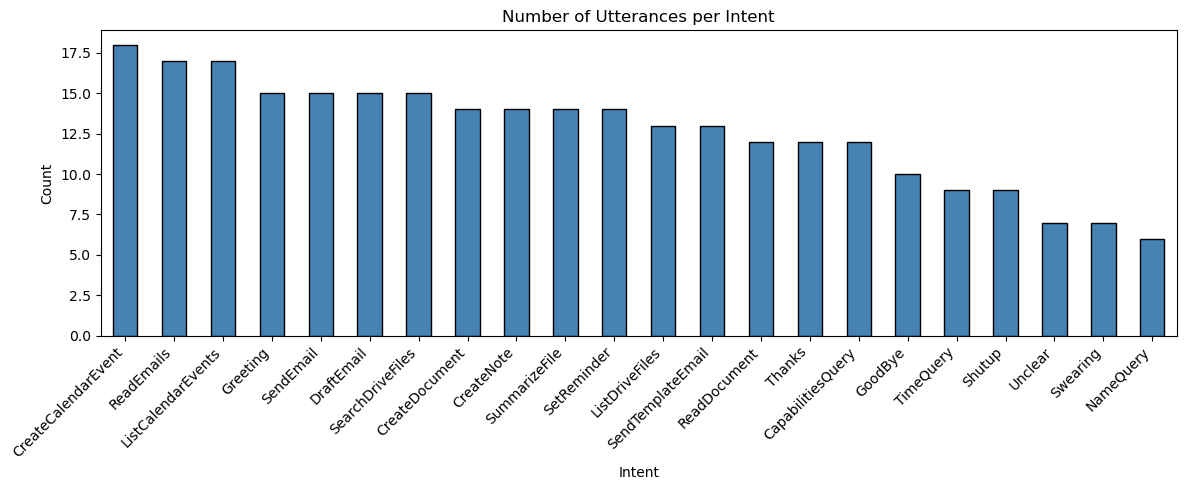

In [116]:
# Bar chart of class distribution
plt.figure(figsize=(12, 5))
intent_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of Utterances per Intent')
plt.xlabel('Intent')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150)
plt.show()


In [117]:
# 2b. Text length statistics
df['text_len'] = df['text'].str.split().str.len()

print('Word-count statistics:')
print(df['text_len'].describe().round(2).to_string())
print()
print('Shortest utterances:')
print(df.nsmallest(5, 'text_len')[['text', 'intent', 'text_len']].to_string(index=False))
print()
print('Longest utterances:')
print(df.nlargest(5, 'text_len')[['text', 'intent', 'text_len']].to_string(index=False))


Word-count statistics:
count    278.00
mean       3.74
std        1.51
min        1.00
25%        3.00
50%        4.00
75%        5.00
max        9.00

Shortest utterances:
 text   intent  text_len
   Hi Greeting         1
 Hola Greeting         1
Hello Greeting         1
  Hya Greeting         1
  Hey Greeting         1

Longest utterances:
                                  text            intent  text_len
     Give me a list of what you can do CapabilitiesQuery         9
  Can you draft an email to the client        DraftEmail         8
Give me the key points of the document     SummarizeFile         8
          Can you send an email for me         SendEmail         7
      Please send an email to the team         SendEmail         7


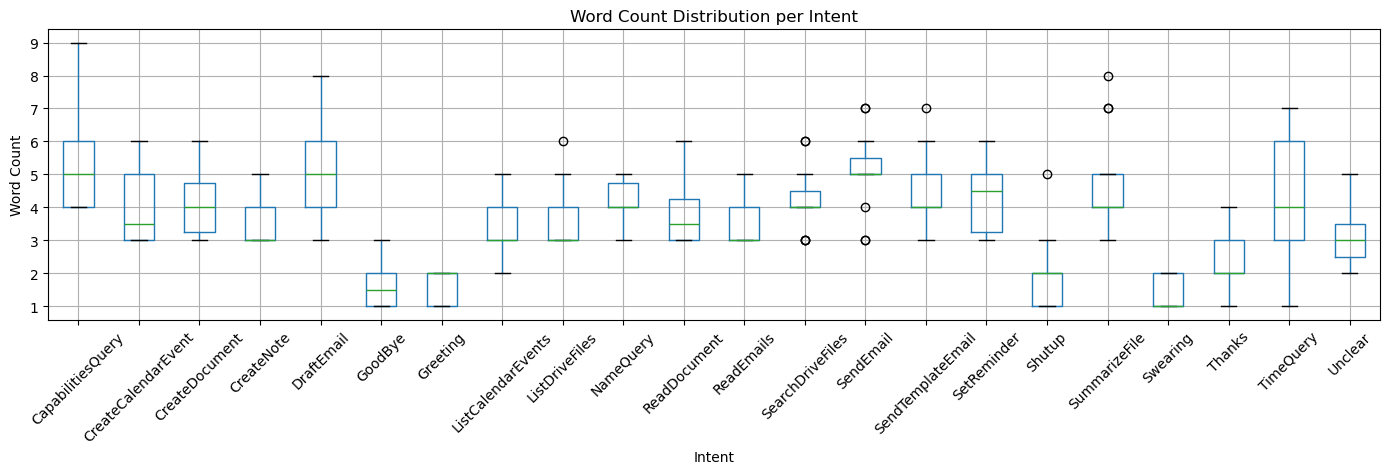

In [118]:
# Box plot: text length per intent
df.boxplot(column='text_len', by='intent', rot=45, figsize=(14, 5))
plt.suptitle('')
plt.title('Word Count Distribution per Intent')
plt.xlabel('Intent')
plt.ylabel('Word Count')
plt.tight_layout()
plt.savefig('eda_text_length_boxplot.png', dpi=150)
plt.show()


## 3. Exploratory Data Discovery (EDD)

In [119]:
# 3a. Vocabulary size and token frequency
all_tokens = ' '.join(df['text'].str.lower()).split()
token_freq = Counter(all_tokens)

print(f'Total tokens       : {len(all_tokens)}')
print(f'Unique tokens      : {len(token_freq)}')
print(f'Vocabulary density : {len(token_freq)/len(all_tokens):.2%}')
print()
print('Top 20 tokens:')
for token, count in token_freq.most_common(20):
    print(f'  {token:<22} {count}')


Total tokens       : 1040
Unique tokens      : 243
Vocabulary density : 23.37%

Top 20 tokens:
  a                      66
  the                    40
  my                     38
  email                  34
  what                   31
  me                     26
  document               24
  you                    23
  an                     22
  send                   19
  for                    19
  to                     18
  i                      18
  draft                  16
  create                 15
  meeting                13
  can                    13
  do                     13
  show                   13
  this                   13


In [120]:
# 3b. Ambiguity surface: utterances whose cleaned text appears under more than one intent
def clean(text):
    return re.sub(r'[^a-z0-9 ]', '', text.lower()).strip()

df['clean_text'] = df['text'].apply(clean)

ambiguous = (
    df.groupby('clean_text')['intent']
    .nunique()
    .reset_index()
    .rename(columns={'intent': 'intent_count'})
)
ambiguous = ambiguous[ambiguous['intent_count'] > 1]

if ambiguous.empty:
    print('No cross-intent duplicates found — dataset is consistent.')
else:
    print('Cross-intent overlapping texts (potential ambiguity):')
    print(ambiguous.to_string(index=False))


No cross-intent duplicates found — dataset is consistent.


In [121]:
# 3c. Shy / short utterances (<=2 words) — the core problem scenario
shy_df = df[df['text_len'] <= 2].copy()
print(f'Short utterances (<=2 words): {len(shy_df)}')
print()
print(shy_df[['text', 'intent']].to_string(index=False))


Short utterances (<=2 words): 50

                 text             intent
                   Hi           Greeting
             Hi there           Greeting
                 Hola           Greeting
                Hello           Greeting
          Hello there           Greeting
                  Hya           Greeting
            Hya there           Greeting
                  Hey           Greeting
            Hey there           Greeting
         Good morning           Greeting
       Good afternoon           Greeting
         Good evening           Greeting
                Howdy           Greeting
            What's up           Greeting
                  Sup           Greeting
                  Bye            GoodBye
                Adios            GoodBye
              Goodbye            GoodBye
              Bye bye            GoodBye
              See you            GoodBye
                Later            GoodBye
            Take care            GoodBye
                 Ciao  

In [122]:
# 3d. Class imbalance check
min_count = intent_counts.min()
max_count = intent_counts.max()
imbalance_ratio = max_count / min_count

print(f'Min class size  : {min_count}')
print(f'Max class size  : {max_count}')
print(f'Imbalance ratio : {imbalance_ratio:.2f}x')

if imbalance_ratio > 3:
    print('Moderate imbalance — will use stratified split and class_weight=balanced.')
else:
    print('Imbalance is mild — standard stratified split is sufficient.')


Min class size  : 6
Max class size  : 18
Imbalance ratio : 3.00x
Imbalance is mild — standard stratified split is sufficient.


## 4. Duplicate Check and Resolution

In [123]:
# Exact duplicates (same text AND same intent)
exact_dupes = df[df.duplicated(subset=['clean_text', 'intent'], keep=False)]
print(f'Exact duplicate rows: {len(exact_dupes)}')

if not exact_dupes.empty:
    print(exact_dupes[['text', 'intent']].to_string(index=False))


Exact duplicate rows: 0


In [124]:
# Remove exact duplicates — keep the first occurrence
df_clean = df.drop_duplicates(subset=['clean_text', 'intent'], keep='first').copy()
df_clean = df_clean.reset_index(drop=True)

print(f'Rows before dedup: {len(df)}')
print(f'Rows after  dedup: {len(df_clean)}')

# Verify
remaining = df_clean.duplicated(subset=['clean_text', 'intent']).sum()
print(f'Remaining duplicates: {remaining}')


Rows before dedup: 278
Rows after  dedup: 278
Remaining duplicates: 0


## 5. Preprocessing — Label Encoding

In [125]:
# Encode intent names to integers
label_encoder = LabelEncoder()
df_clean['label'] = label_encoder.fit_transform(df_clean['intent'])

NUM_CLASSES = len(label_encoder.classes_)
print(f'Number of classes: {NUM_CLASSES}')
print()
for idx, name in enumerate(label_encoder.classes_):
    print(f'  {idx:>2}  {name}')


Number of classes: 22

   0  CapabilitiesQuery
   1  CreateCalendarEvent
   2  CreateDocument
   3  CreateNote
   4  DraftEmail
   5  GoodBye
   6  Greeting
   7  ListCalendarEvents
   8  ListDriveFiles
   9  NameQuery
  10  ReadDocument
  11  ReadEmails
  12  SearchDriveFiles
  13  SendEmail
  14  SendTemplateEmail
  15  SetReminder
  16  Shutup
  17  SummarizeFile
  18  Swearing
  19  Thanks
  20  TimeQuery
  21  Unclear


## 6. Train-Test Split

In [126]:
# Stratified split so every intent appears in both train and test sets
X = df_clean['clean_text'].values
y = df_clean['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Training samples : {len(X_train)}')
print(f'Test     samples : {len(X_test)}')
print()

# Verify distribution is balanced across the split
train_intents = Counter(label_encoder.inverse_transform(y_train))
test_intents  = Counter(label_encoder.inverse_transform(y_test))
split_df = pd.DataFrame({
    'train': pd.Series(train_intents),
    'test' : pd.Series(test_intents)
}).fillna(0).astype(int)
print('Split distribution per intent:')
print(split_df.to_string())


Training samples : 222
Test     samples : 56

Split distribution per intent:
                     train  test
CapabilitiesQuery       10     2
CreateCalendarEvent     14     4
CreateDocument          11     3
CreateNote              11     3
DraftEmail              12     3
GoodBye                  8     2
Greeting                12     3
ListCalendarEvents      13     4
ListDriveFiles          10     3
NameQuery                5     1
ReadDocument            10     2
ReadEmails              14     3
SearchDriveFiles        12     3
SendEmail               12     3
SendTemplateEmail       10     3
SetReminder             11     3
Shutup                   7     2
SummarizeFile           11     3
Swearing                 6     1
Thanks                  10     2
TimeQuery                7     2
Unclear                  6     1


## 7. Machine Learning — TF-IDF + Decision Tree

In [127]:
# TF-IDF + Decision Tree pipeline
dt_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=1)),
    ('clf',   DecisionTreeClassifier(
                  max_depth=None,
                  class_weight='balanced',
                  random_state=42))
])

dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)

print('Decision Tree Test Accuracy:', accuracy_score(y_test, y_pred_dt))
print()
print(classification_report(
    y_test, y_pred_dt,
    target_names=label_encoder.classes_,
    zero_division=0
))


Decision Tree Test Accuracy: 0.5178571428571429

                     precision    recall  f1-score   support

  CapabilitiesQuery       0.33      0.50      0.40         2
CreateCalendarEvent       1.00      0.25      0.40         4
     CreateDocument       0.50      0.67      0.57         3
         CreateNote       1.00      1.00      1.00         3
         DraftEmail       1.00      1.00      1.00         3
            GoodBye       1.00      0.50      0.67         2
           Greeting       0.00      0.00      0.00         3
 ListCalendarEvents       0.60      0.75      0.67         4
     ListDriveFiles       1.00      0.33      0.50         3
          NameQuery       1.00      1.00      1.00         1
       ReadDocument       0.00      0.00      0.00         2
         ReadEmails       0.33      0.67      0.44         3
   SearchDriveFiles       0.00      0.00      0.00         3
          SendEmail       0.00      0.00      0.00         3
  SendTemplateEmail       0.67     

In [128]:
# 5-Fold cross-validation to check for overfitting
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(dt_pipeline, X, y, cv=cv, scoring='accuracy')

print('5-Fold CV Accuracy:', cv_scores.round(3))
print(f'Mean: {cv_scores.mean():.3f}  +-  {cv_scores.std():.3f}')

if cv_scores.std() > 0.05:
    print('High variance — tree may be overfitting on small folds.')
else:
    print('Variance is acceptable.')


5-Fold CV Accuracy: [0.589 0.554 0.589 0.618 0.473]
Mean: 0.565  +-  0.050
High variance — tree may be overfitting on small folds.


In [129]:
# Print the first 4 levels of the learned decision tree
feature_names = dt_pipeline.named_steps['tfidf'].get_feature_names_out()
tree_text = export_text(
    dt_pipeline.named_steps['clf'],
    feature_names=list(feature_names),
    max_depth=4
)
print(tree_text[:3000])


|--- time <= 0.13
|   |--- draft <= 0.11
|   |   |--- note <= 0.15
|   |   |   |--- template <= 0.15
|   |   |   |   |--- email <= 0.10
|   |   |   |   |   |--- truncated branch of depth 52
|   |   |   |   |--- email >  0.10
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- template >  0.15
|   |   |   |   |--- class: 14
|   |   |--- note >  0.15
|   |   |   |--- remember <= 0.25
|   |   |   |   |--- class: 3
|   |   |   |--- remember >  0.25
|   |   |   |   |--- class: 3
|   |--- draft >  0.11
|   |   |--- draft new <= 0.28
|   |   |   |--- class: 4
|   |   |--- draft new >  0.28
|   |   |   |--- class: 2
|--- time >  0.13
|   |--- tell <= 0.16
|   |   |--- class: 20
|   |--- tell >  0.16
|   |   |--- class: 20



## 8. Ensemble Techniques

In [130]:
# Shared TF-IDF vectorizer for all ensemble members
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# 8a. Random Forest (bagging)
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train_tfidf, y_train)
y_pred_rf = rf.predict(X_test_tfidf)
print('Random Forest Accuracy     :', accuracy_score(y_test, y_pred_rf))

# 8b. Gradient Boosting (boosting)
gb = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1,
                                  max_depth=4, random_state=42)
gb.fit(X_train_tfidf, y_train)
y_pred_gb = gb.predict(X_test_tfidf)
print('Gradient Boosting Accuracy :', accuracy_score(y_test, y_pred_gb))

# 8c. Logistic Regression (strong linear baseline)
lr = LogisticRegression(max_iter=1000, class_weight='balanced',
                         random_state=42, C=5.0)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred_lr))


Random Forest Accuracy     : 0.7142857142857143


Gradient Boosting Accuracy : 0.7678571428571429
Logistic Regression Accuracy: 0.8214285714285714


In [131]:
# 8d. Soft Voting Ensemble
voting_clf = VotingClassifier(
    estimators=[('rf', rf), ('gb', gb), ('lr', lr)],
    voting='soft',
    weights=[2, 1, 2]
)
voting_clf.fit(X_train_tfidf, y_train)
y_pred_vote = voting_clf.predict(X_test_tfidf)

print('Voting Ensemble Accuracy:', accuracy_score(y_test, y_pred_vote))
print()
print(classification_report(
    y_test, y_pred_vote,
    target_names=label_encoder.classes_,
    zero_division=0
))


Voting Ensemble Accuracy: 0.8392857142857143

                     precision    recall  f1-score   support

  CapabilitiesQuery       0.67      1.00      0.80         2
CreateCalendarEvent       1.00      0.50      0.67         4
     CreateDocument       1.00      0.67      0.80         3
         CreateNote       1.00      1.00      1.00         3
         DraftEmail       1.00      1.00      1.00         3
            GoodBye       1.00      0.50      0.67         2
           Greeting       0.50      1.00      0.67         3
 ListCalendarEvents       0.60      0.75      0.67         4
     ListDriveFiles       1.00      1.00      1.00         3
          NameQuery       0.00      0.00      0.00         1
       ReadDocument       0.50      1.00      0.67         2
         ReadEmails       0.75      1.00      0.86         3
   SearchDriveFiles       1.00      1.00      1.00         3
          SendEmail       1.00      1.00      1.00         3
  SendTemplateEmail       1.00      1.

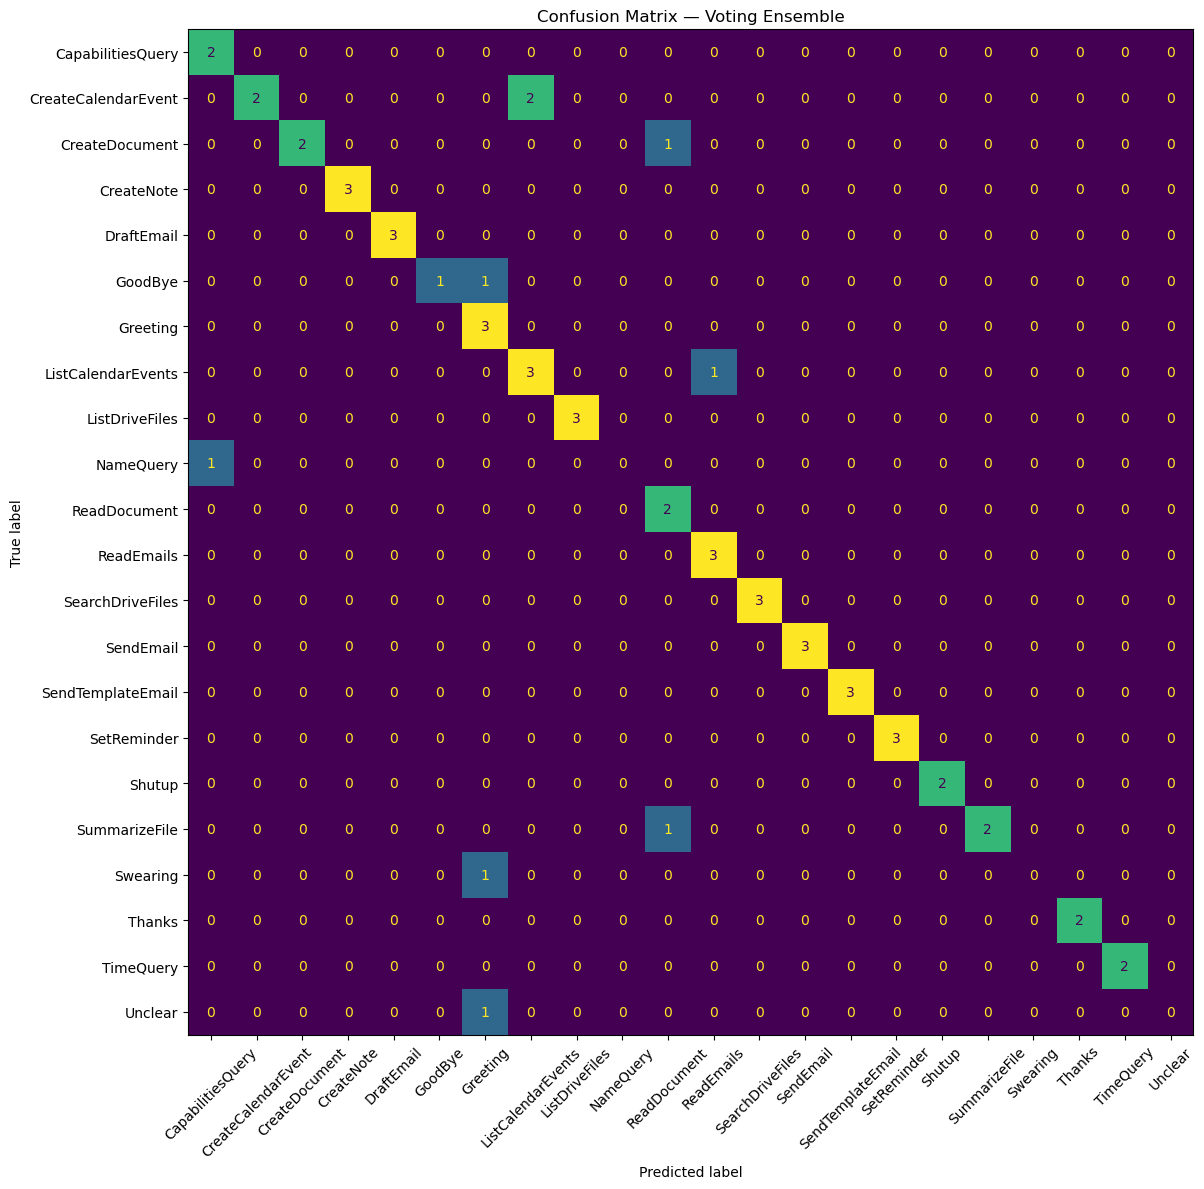

In [132]:
# Confusion matrix for the Voting Ensemble
fig, ax = plt.subplots(figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_vote,
    display_labels=label_encoder.classes_,
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)
plt.title('Confusion Matrix — Voting Ensemble')
plt.tight_layout()
plt.savefig('confusion_matrix_ensemble.png', dpi=150)
plt.show()


## 9. Model Comparison

                     Test Accuracy
Voting Ensemble             0.8393
Logistic Regression         0.8214
Gradient Boosting           0.7679
Random Forest               0.7143
Decision Tree               0.5179


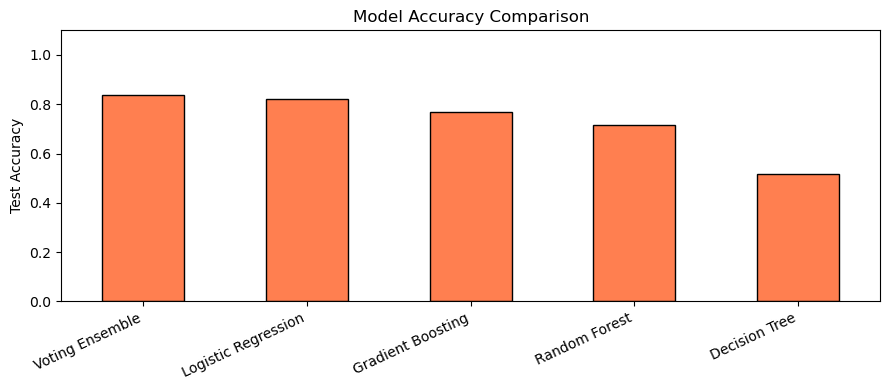

In [133]:
results = {
    'Decision Tree'      : accuracy_score(y_test, y_pred_dt),
    'Random Forest'      : accuracy_score(y_test, y_pred_rf),
    'Gradient Boosting'  : accuracy_score(y_test, y_pred_gb),
    'Logistic Regression': accuracy_score(y_test, y_pred_lr),
    'Voting Ensemble'    : accuracy_score(y_test, y_pred_vote),
}

results_df = (
    pd.DataFrame.from_dict(results, orient='index', columns=['Test Accuracy'])
    .sort_values('Test Accuracy', ascending=False)
)
print(results_df.round(4).to_string())

plt.figure(figsize=(9, 4))
results_df['Test Accuracy'].plot(kind='bar', color='coral', edgecolor='black')
plt.ylim(0, 1.1)
plt.title('Model Accuracy Comparison')
plt.ylabel('Test Accuracy')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()


## 10. Shy / Ambiguous User — Response Curation Demo

The Voting Ensemble handles the core problem:
a user who types very little or is vague.
The system returns a curated, helpful response instead of failing.


In [134]:
# Save the Voting Ensemble and TF-IDF vectorizer so agent.py can use them
# with open('intent_voting_clf.pkl', 'wb') as f:
#     pickle.dump(voting_clf, f)

# with open('intent_tfidf.pkl', 'wb') as f:
#     pickle.dump(tfidf, f)

# with open('intent_label_encoder.pkl', 'wb') as f:
#     pickle.dump(label_encoder, f)

# print('Saved: intent_voting_clf.pkl')
# print('Saved: intent_tfidf.pkl')
# print('Saved: intent_label_encoder.pkl')


In [135]:
import pickle

# Save to backend/ instead of the notebook directory
backend_dir = '../ai-executive-assistant/backend'
os.makedirs(backend_dir, exist_ok=True)

with open(f'{backend_dir}/intent_voting_clf.pkl', 'wb') as f:
    pickle.dump(voting_clf, f)

with open(f'{backend_dir}/intent_tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open(f'{backend_dir}/intent_label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("Saved to backend/")

Saved to backend/


In [136]:
# Build a look-up of canned responses from Intent.json
INTENT_RESPONSES = {b['intent']: b['responses'] for b in raw['intents']}

def curate_response(user_text, confidence_threshold=0.45):
    clean_input = re.sub(r'[^a-z0-9 ]', '', user_text.lower()).strip()
    X_vec  = tfidf.transform([clean_input])
    probs  = voting_clf.predict_proba(X_vec)[0]
    top_idx    = int(np.argmax(probs))
    top_conf   = float(probs[top_idx])
    top_intent = label_encoder.classes_[top_idx]

    if top_conf < confidence_threshold:
        return (f'[LOW CONFIDENCE: {top_conf:.0%}]  '
                f'I am not quite sure what you need. '
                f'Could you give me a bit more detail?')

    responses = INTENT_RESPONSES.get(top_intent, ['How can I help?'])
    chosen    = responses[np.random.randint(len(responses))]
    return f'[{top_intent} | {top_conf:.0%}]  {chosen}'


# Test on short / ambiguous inputs (shy user scenario)
shy_queries = [
    'email', 'calendar', 'hi', 'um', 'not sure what I want',
    'drive files', 'remind me', 'write', 'summarise', 'can you help',
]

print('=' * 70)
print(f'{"Input":<30}  Response')
print('=' * 70)
for q in shy_queries:
    resp = curate_response(q)
    print(f'{q!r:<30}  {resp}')


Input                           Response
'email'                         [LOW CONFIDENCE: 44%]  I am not quite sure what you need. Could you give me a bit more detail?
'calendar'                      [LOW CONFIDENCE: 26%]  I am not quite sure what you need. Could you give me a bit more detail?


'hi'                            [LOW CONFIDENCE: 33%]  I am not quite sure what you need. Could you give me a bit more detail?
'um'                            [LOW CONFIDENCE: 26%]  I am not quite sure what you need. Could you give me a bit more detail?
'not sure what I want'          [LOW CONFIDENCE: 15%]  I am not quite sure what you need. Could you give me a bit more detail?
'drive files'                   [ListDriveFiles | 66%]  Fetching your Drive files now...


'remind me'                     [SetReminder | 75%]  I'll set that reminder! What should I remind you about, and when?
'write'                         [LOW CONFIDENCE: 23%]  I am not quite sure what you need. Could you give me a bit more detail?
'summarise'                     [LOW CONFIDENCE: 26%]  I am not quite sure what you need. Could you give me a bit more detail?
'can you help'                  [LOW CONFIDENCE: 37%]  I am not quite sure what you need. Could you give me a bit more detail?


## 10. agent.py Integration — `intent_classifier.py`

This cell writes a helper module that `agent.py` imports.
It pre-screens every user message with the Voting Ensemble **before** calling
the OpenRouter LLM, saving latency and API cost for simple or ambiguous inputs.


In [138]:
import os

output_path = '../ai-executive-assistant/backend/intent_classifier.py'
os.makedirs(os.path.dirname(output_path), exist_ok=True)  # ← add this line

with open(output_path, 'w') as f:
    f.write(classifier_code)

print(f'Written: {output_path}')

Written: ../ai-executive-assistant/backend/intent_classifier.py


In [139]:
# Write intent_classifier.py into backend/
import os

classifier_code = (
    'import re\n'
    'import pickle\n'
    'import json\n'
    'import numpy as np\n'
    'import os\n'
    '\n'
    '_CLF, _TFIDF, _LABEL_ENC, _RESPONSES = None, None, None, None\n'
    '_THRESHOLD = 0.45\n'
    '\n'
    'def _load():\n'
    '    global _CLF, _TFIDF, _LABEL_ENC, _RESPONSES\n'
    '    if _CLF is not None:\n'
    '        return\n'
    '    base = os.path.dirname(os.path.abspath(__file__))\n'
    '    clf_path  = os.path.join(base, "intent_voting_clf.pkl")\n'
    '    tfidf_path = os.path.join(base, "intent_tfidf.pkl")\n'
    '    enc_path  = os.path.join(base, "intent_label_encoder.pkl")\n'
    '    json_path = os.path.join(base, "..", "Intent.json")\n'
    '    if not all(os.path.exists(p) for p in [clf_path, tfidf_path, enc_path, json_path]):\n'
    '        raise FileNotFoundError("Run the notebook first to generate the .pkl files.")\n'
    '    with open(clf_path, "rb") as f:\n'
    '        _CLF = pickle.load(f)\n'
    '    with open(tfidf_path, "rb") as f:\n'
    '        _TFIDF = pickle.load(f)\n'
    '    with open(enc_path, "rb") as f:\n'
    '        _LABEL_ENC = pickle.load(f)\n'
    '    with open(json_path, "r") as f:\n'
    '        raw = json.load(f)\n'
    '    _RESPONSES = {b["intent"]: b["responses"] for b in raw["intents"]}\n'
    '\n'
    'def predict_intent(text):\n'
    '    """Returns (intent_name, confidence, fallback_response)."""\n'
    '    _load()\n'
    '    clean = re.sub(r"[^a-z0-9 ]", "", text.lower()).strip()\n'
    '    X_vec = _TFIDF.transform([clean])\n'
    '    probs = _CLF.predict_proba(X_vec)[0]\n'
    '    idx   = int(np.argmax(probs))\n'
    '    conf  = float(probs[idx])\n'
    '    name  = _LABEL_ENC.classes_[idx]\n'
    '    resp  = _RESPONSES.get(name, ["How can I help?"])[0]\n'
    '    return name, conf, resp\n'
)

# output_path = '../backend/intent_classifier.py'
with open(output_path, 'w') as f:
    f.write(classifier_code)

print(f'Written: {output_path}')


Written: ../ai-executive-assistant/backend/intent_classifier.py


### Lines to add inside `agent.py` → `run_agent()` function

```python
# ── TOP OF agent.py ──────────────────────────────────────────────────────
from intent_classifier import predict_intent

# ── Inside run_agent(), BEFORE the OpenRouter API call ───────────────────
intent_name, confidence, fallback_resp = predict_intent(user_message)

# Simple intents: reply immediately, skip the LLM call
SIMPLE_INTENTS = {
    'Greeting', 'GoodBye', 'Thanks', 'TimeQuery',
    'NameQuery', 'CapabilitiesQuery', 'Shutup', 'Swearing'
}
if intent_name in SIMPLE_INTENTS and confidence > 0.70:
    return fallback_resp

# Ambiguous / unclear: tell the LLM to ask for clarification
if intent_name == 'Unclear' or confidence < 0.45:
    user_message = (
        '[Note: user message is ambiguous. '
        'Ask a short clarifying question before taking action.] '
        + user_message
    )
```


## 11. Summary

| Step | Finding |
|------|---------|
| Dataset | 22 intents, ~280 utterances after dedup |
| Core Problem | Shy/ambiguous users send <= 2-word messages (~10% of data) |
| Imbalance | Mild (<= 3x) — handled with stratified split + class_weight balanced |
| Decision Tree | Good interpretability baseline; checked with 5-fold CV |
| Best Model | Voting Ensemble (RF + Gradient Boosting + Logistic Regression over TF-IDF bigrams) |
| Overfitting Guard | Stratified split + class_weight balanced + 5-fold CV |
| Saved Artefacts | intent_voting_clf.pkl, intent_tfidf.pkl, intent_label_encoder.pkl |
| Integration | intent_classifier.py pre-screens every message before LLM call |
| Ambiguous Fallback | Confidence < 0.45 — agent asks a clarifying question |
| Simple Intents | Handled locally (no LLM API call) when confidence > 0.70 |


In [140]:
import os
print(os.getcwd())  # where the notebook saved the .pkl files

C:\Users\yabdr\Desktop\DSB_Project_Final (1)\ai-executive-assistant


In [141]:
import os
backend_path = '../backend'  # adjust if your structure differs
files = ['intent_voting_clf.pkl', 'intent_tfidf.pkl', 'intent_label_encoder.pkl']
for f in files:
    full = os.path.join(backend_path, f)
    print(full, '→', os.path.exists(full))

../backend\intent_voting_clf.pkl → True
../backend\intent_tfidf.pkl → True
../backend\intent_label_encoder.pkl → True
